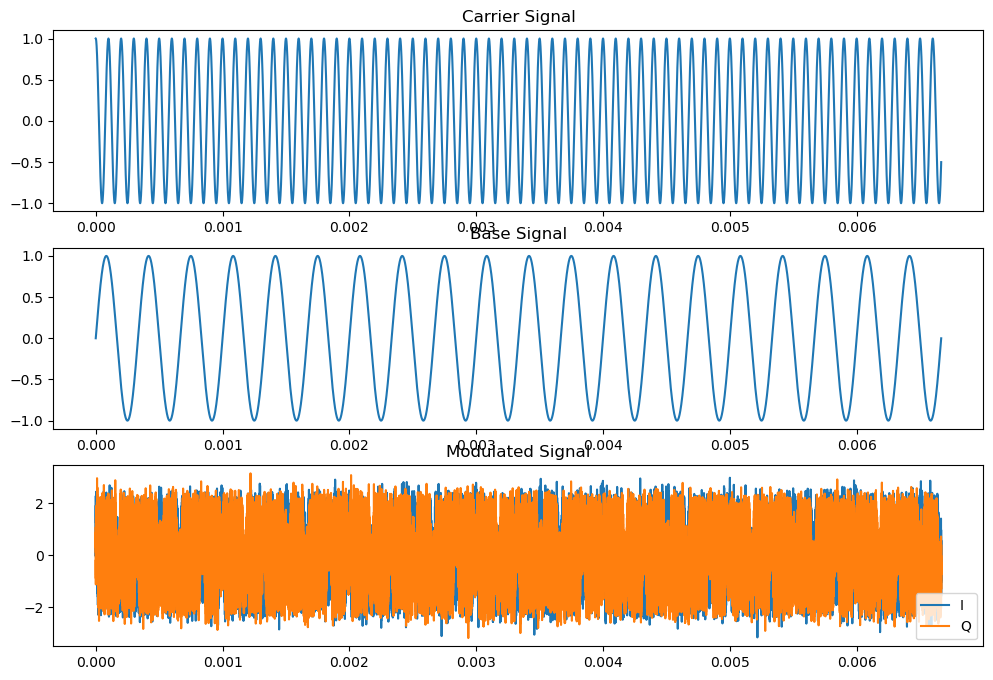

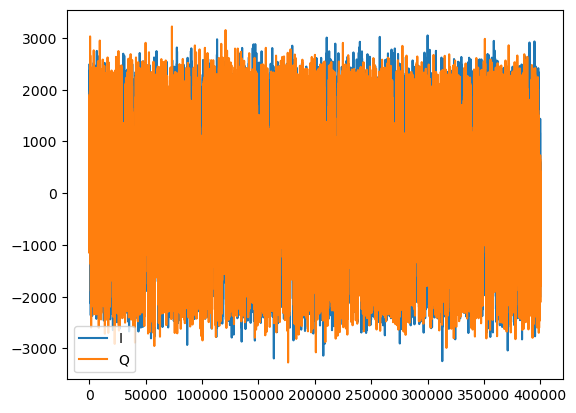

In [8]:
# fm调制

import numpy as np
import matplotlib.pyplot as plt

# 采样率
fsp = 60_000_000

# 最大频偏
fmax = 75_000

# 信号带宽
fb = 3_000

# 载波频率
fc = 10_000

T_NUM = 400_000

# 生成载波信号
t = np.linspace(0, T_NUM / fsp, T_NUM, endpoint=False)
carrier = np.cos(2 * np.pi * fc * t)

# 生成基带信号
base_signal = np.sin(2 * np.pi * fb * t)

# 生成调制信号
modulated_signal = np.zeros(T_NUM, dtype=np.complex128)

phase = 0
for i in range(T_NUM):
    phase += 2 * np.pi * (fc + fmax * base_signal[i]) * 1 / fsp
    modulated_signal[i] = np.exp(1j * phase)

# 加上noise
modulated_signal += (np.random.randn(T_NUM) + 1j * np.random.randn(T_NUM)) * 0.5

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(t, carrier)
plt.title("Carrier Signal")

plt.subplot(3, 1, 2)
plt.plot(t, base_signal)
plt.title("Base Signal")

plt.subplot(3, 1, 3)
plt.plot(t, modulated_signal.real, label="I")
plt.plot(t, modulated_signal.imag, label="Q")
plt.legend()
plt.title("Modulated Signal")
plt.show()

# 保存为二进制文件 
# 补码
def get_twos_complement(array, bits):
    array = array.astype(np.int32)
    # 截位
    array = np.clip(array, -(1 << (bits - 1)), (1 << (bits - 1)) - 1)
    return np.where(array >= 0, array, (1 << bits) + array)

sample_width = 12
scale = 2**(sample_width-2)

plt.plot(modulated_signal.real*scale, label="I")
plt.plot(modulated_signal.imag*scale, label="Q")
plt.legend()
plt.show()

real = get_twos_complement(modulated_signal.real*scale, sample_width)
imag = get_twos_complement(modulated_signal.imag*scale, sample_width)



np.savetxt("./tb/fm_modulated_signal.txt", real * 2**sample_width + imag, fmt="%X")

Gain Width: 9 bits


C:\Temp\ipykernel_6600\3953515945.py:51: RuntimeWarning: invalid value encountered in divide
  H = (np.sin(np.pi * f * self.R * self.M) / np.sin(np.pi * f)) ** self.N


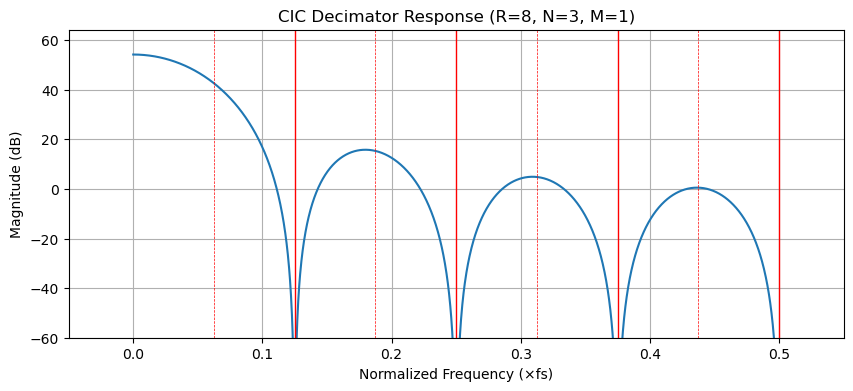

In [9]:
class CICDecimator:
    def __init__(self, WIDTH=16, R=2, M=1, N=2):
        """
        CIC Decimator (信号特性仿真)
        
        参数:
        WIDTH : 输入位宽 (仅用于信息，不参与数值计算)
        R     : 抽取率 (固定)
        M     : 差分延迟
        N     : 阶数
        """
        # self.WIDTH = WIDTH
        self.R = R
        self.M = M
        self.N = N
        # 计算内部寄存器总位宽 (与 Verilog 一致)
        # self.REG_WIDTH = int(WIDTH + np.ceil(np.log2((R * M) ** N)))

    # -----------------------------------------------------
    # 主滤波器过程（理想行为，积分+抽取+梳状）
    # -----------------------------------------------------
    def process(self, x):
        """
        处理输入信号 x (numpy 数组)
        返回抽取后的滤波信号
        """
        # 积分部分：N级积分
        integ = np.copy(x)
        for _ in range(self.N):
            integ = np.cumsum(integ)

        # 抽取
        decimated = integ[::self.R]

        # 梳状部分：N级差分 (差分延迟为 M)
        comb = np.copy(decimated)
        for _ in range(self.N):
            comb = comb - np.concatenate((np.zeros(self.M), comb[:-self.M]))

        return comb

    # -----------------------------------------------------
    # 理论频率响应
    # -----------------------------------------------------
    def plot_response(self, fs=1.0):
        """
        绘制理论频率响应（归一化频率）
        """
        f = np.linspace(0, 0.5, 2048)
        # 理论幅频响应
        H = (np.sin(np.pi * f * self.R * self.M) / np.sin(np.pi * f)) ** self.N
        H[np.isnan(H)] = (self.R * self.M) ** self.N  # f=0 点
        H = np.abs(H)

        dB = 20 * np.log10(H)

        plt.figure(figsize=(10, 4))
        plt.plot(f, dB)
        # 设置y范围下限为-60dB
        plt.ylim(-60, np.max(dB) + 10)
        plt.xlim(-0.05, 0.55)
        plt.title(f"CIC Decimator Response (R={self.R}, N={self.N}, M={self.M})")
        plt.xlabel("Frequency (Hz)" if fs != 1.0 else "Normalized Frequency (×fs)")
        plt.ylabel("Magnitude (dB)")
        plt.grid(True)

        # 画出抽取后循环的边界
        for i in range(1, self.R):
            plt.axvline(x=i / self.R, color='r', linestyle='-', linewidth=1)
            plt.axvline(x=(-0.5+i) / self.R, color='r', linestyle='--', linewidth=0.5)

        plt.show()

    def get_gain_width(self):
        """
        获取增益宽度 (Gain Width)
        """
        return int(np.ceil(np.log2((self.R * self.M) ** self.N)))

cic_decimator = CICDecimator(R=8, M=1, N=3)
print(f"Gain Width: {cic_decimator.get_gain_width()} bits")
cic_decimator.plot_response()

C:\Temp\ipykernel_6600\3861295978.py:104: RuntimeWarning: invalid value encountered in divide
  H = (np.sin(np.pi * f * self.R * self.M) / np.sin(np.pi * f)) ** self.N


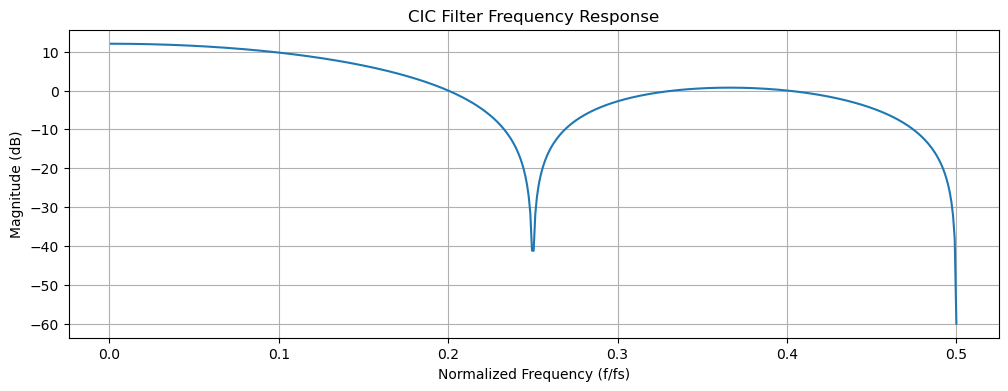

In [10]:
import numpy as np
import matplotlib.pyplot as plt

class CICFilter:
    def __init__(self, R=32, N=1, M=1, max_bits=16, fs=200000):
        """
        CIC滤波器类
        
        参数:
        R: 抽取率 (默认: 32)
        N: 级数 (默认: 1)
        M: 差分延迟 (默认: 1)
        max_bits: 最大位数 (默认: 16)
        fs: 采样频率 (默认: 200000 Hz)
        """
        self.R = R
        self.N = N
        self.M = M
        self.MAX_BITS = max_bits
        self.FS = fs
        self.P = int(R / 2)  # 采样相位
        
    def integrator(self, ins):
        """积分器"""
        reg = 0
        out = np.zeros(ins.size, dtype=ins.dtype)
        for i in range(ins.size):
            out[i] = ins[i] + reg
            reg = out[i]
        return out
    
    def integrator_q(self, ins, R_bits):
        """量化积分器"""
        reg = 0
        out = np.zeros(ins.size, dtype=ins.dtype)
        for i in range(ins.size):
            out[i] = np.fmod(ins[i] + reg, 2**(self.MAX_BITS + R_bits - 1))
            reg = out[i]
        return out
    
    def comb(self, ins, M, R):
        """梳状滤波器"""
        delay = np.zeros(ins.size, dtype=ins.dtype)
        delay[M:] = ins[0:-M]
        return (ins - delay) / R * M
    
    def comb_q(self, ins, M, R_bits):
        """量化梳状滤波器"""
        delay = np.zeros(ins.size, dtype=ins.dtype)
        delay[M:] = ins[0:-M]
        comb_out = np.floor((ins - delay) * 2**(self.MAX_BITS + R_bits - 1)) / 2**(self.MAX_BITS + R_bits - 1)
        comb_out_q = np.floor((comb_out / 2**R_bits) * 2**(self.MAX_BITS - 1)) / 2**(self.MAX_BITS - 1)
        
        return np.clip(comb_out_q, -1, (2**(self.MAX_BITS - 1) - 1) / 2**(self.MAX_BITS - 1))
    
    def sample(self, ins, R, P):
        """采样器"""
        sample_num = int((ins.size - P) / R)
        inte_samp = np.zeros(sample_num, dtype=ins.dtype)
        for i in range(sample_num):
            inte_samp[i] = ins[i * R + P]
        return inte_samp
    
    def process(self, ins, quantized=True):
        """
        CIC滤波器处理
        
        参数:
        ins: 输入信号
        quantized: 是否使用量化版本 (默认: True)
        
        返回:
        处理后的信号
        """
        if quantized:
            return self.CIC_Q(ins)
        else:
            return self.CIC(ins)
    
    def CIC(self, ins):
        """非量化CIC滤波器"""
        inte_out = self.integrator(ins)
        inte_samp = self.sample(inte_out, self.R, self.P)
        comb_out = self.comb(inte_samp, self.M, self.R)
        return comb_out
    
    def CIC_Q(self, ins):
        """量化CIC滤波器"""
        Q = int(np.log2(self.R))
        inte_out = self.integrator_q(ins, Q)
        inte_samp = self.sample(inte_out, self.R, self.P)
        comb_out = self.comb_q(inte_samp, self.M, Q)
        return comb_out
    
    def plot_response(self):
        """
        绘制CIC滤波器的频率响应
        """
        from scipy.signal import freqz

        # H(f) = \left( \frac{\sin(\pi f R M)}{\sin(\pi f)} \right)^N
        
        f = np.linspace(0, 0.5, 512)
        H = (np.sin(np.pi * f * self.R * self.M) / np.sin(np.pi * f)) ** self.N

        dB = 20 * np.log10(np.abs(H))
        dB = np.clip(dB, -60, 100)  # 限制dB范围以便于可视化
        plt.figure(figsize=(12, 4))
        plt.plot(f, dB)
        plt.title("CIC Filter Frequency Response")
        plt.xlabel("Normalized Frequency (f/fs)")
        plt.ylabel("Magnitude (dB)")
        plt.grid()
        plt.show()

cic_filter = CICFilter(R=2, M=2)
cic_filter.plot_response()

Gain Width: 3 bits
Gain Width: 3 bits
6250
Gain Width: 10 bits


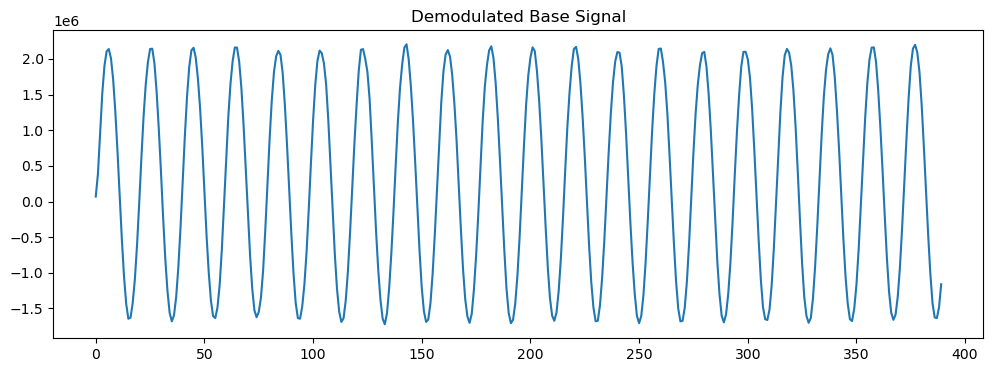

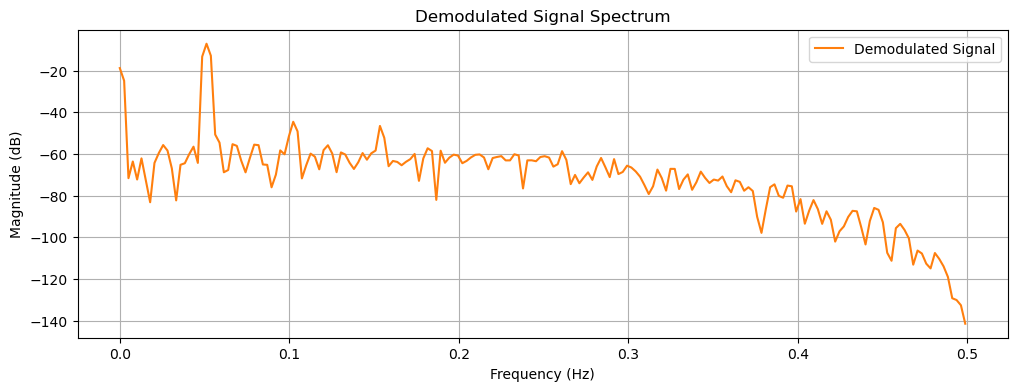

In [17]:
# 解调
# 下采样
cic_filter = CICDecimator(R=8, M=1, N=1)
print(f"Gain Width: {cic_filter.get_gain_width()} bits")

downsampled_signal = cic_filter.process(modulated_signal)
# plt.plot(downsampled_signal)
# plt.show()

cic_filter = CICDecimator(R=8, M=1, N=1)
print(f"Gain Width: {cic_filter.get_gain_width()} bits")

downsampled_signal = cic_filter.process(downsampled_signal)
# plt.plot(downsampled_signal)
# plt.show()

T_NUM = len(downsampled_signal)
print(T_NUM)

i = downsampled_signal.real
q = downsampled_signal.imag

base_demodulated = np.zeros(T_NUM - 1)

for n in range(1, T_NUM):
    base_demodulated[n - 1] = (i[n - 1] * q[n] - i[n] * q[n - 1])

cic_filter = CICDecimator(R=16, M=2, N=2)
print(f"Gain Width: {cic_filter.get_gain_width()} bits")
base_demodulated = cic_filter.process(base_demodulated)
# print(f"Gain Width: {cic_filter.get_gain_width()} bits")
# base_demodulated = cic_filter.process(base_demodulated)

plt.figure(figsize=(12, 4))
plt.plot(base_demodulated[1:])
plt.title("Demodulated Base Signal")
plt.show()

# 频谱
plt.figure(figsize=(12, 4))
plt.magnitude_spectrum(base_demodulated/np.max(base_demodulated), Fs=1, scale='dB', color='C1', label='Demodulated Signal')
plt.title("Demodulated Signal Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.legend()
plt.show()

In [12]:
np.log2(8791798054912)

42.99929538702341

In [13]:
np.log2(2047*2048)

21.99929538702341